# BOmega算法更新诊断工具

本notebook用于诊断BOmega算法中B和Omega更新各自对目标函数的影响

In [9]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.append(r"C:\Users\super\DAG")
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from MEC import is_in_markov_equiv_class
from SCM_data import generate_scm_from_BN
from coordinate_descent.cd_B_Omega import (
    ell, 
    is_DAG, 
    weight_to_adjacency,
    update_Omega_closed_form,
    update_off_diagonal_BOmega
)
from coordinate_descent.cd_B import f_B

print(f"Working directory: {os.getcwd()}")

Working directory: c:\Users\super\DAG\experiments


## 1. 增强版BOmega算法（带详细诊断）

In [10]:
def dag_coordinate_descent_BOmega_diagnostic(
    S: np.ndarray,
    Omega_init: np.ndarray,
    n_epochs: int = 100,
    seed: int = 0,
    threshold: float = 0.05,
    lambda_l0: float = 0.0,
    k = None,
    dag_tol: float = 1e-8,
    eps_omega: float = 1e-8,
    verbose: bool = True,
):
    """
    增强版BOmega算法，记录每个epoch中B更新和Omega更新各自的贡献
    
    Returns:
        B: 最终的B矩阵
        G: 最终的邻接矩阵
        final_score: 最终目标函数值
        diagnostic_data: 包含详细诊断信息的字典
    """
    np.random.seed(seed)
    d = S.shape[0]
    B = np.zeros((d, d))
    Omega_curr = Omega_init.copy()
    
    edge_pairs = [(i, j) for i in range(d) for j in range(i + 1, d)]
    
    # 诊断数据结构
    diagnostic_data = {
        'epoch': [],
        'score_before_B_update': [],
        'score_after_B_update': [],
        'score_after_Omega_update': [],
        'B_contribution': [],  # B更新导致的分数变化
        'Omega_contribution': [],  # Omega更新导致的分数变化
        'total_change': [],  # 总体分数变化
        'B_improves': [],  # B更新是否改善（降低）分数
        'Omega_improves': [],  # Omega更新是否改善分数
        'B_worsens': [],  # B更新是否恶化（增加）分数
        'Omega_worsens': [],  # Omega更新是否恶化分数
        'B_matrix_changes': [],  # B矩阵变化的Frobenius范数
        'Omega_matrix_changes': [],  # Omega矩阵变化的Frobenius范数
    }
    
    for epoch in range(1, n_epochs + 1):
        # 记录epoch开始时的状态
        score_before = ell(B, Omega_curr, S)
        B_before = B.copy()
        Omega_before = Omega_curr.copy()
        
        # ========== 阶段1: 更新B矩阵 ==========
        np.random.shuffle(edge_pairs)
        for (i, j) in edge_pairs:
            B = update_off_diagonal_BOmega(
                B, Omega_curr, S, i, j,
                lambda_l0=lambda_l0, k=k, dag_tol=dag_tol,
                debug_list=None
            )
        
        # 记录B更新后的状态（Omega还未更新）
        score_after_B = ell(B, Omega_curr, S)
        B_change = np.linalg.norm(B - B_before, 'fro')
        
        # ========== 阶段2: 更新Omega矩阵 ==========
        Omega_curr = update_Omega_closed_form(B, S, eps=eps_omega)
        
        # 记录Omega更新后的状态（epoch结束）
        score_after_Omega = ell(B, Omega_curr, S)
        Omega_change = np.linalg.norm(Omega_curr - Omega_before, 'fro')
        
        # ========== 计算贡献和变化 ==========
        B_contribution = score_after_B - score_before
        Omega_contribution = score_after_Omega - score_after_B
        total_change = score_after_Omega - score_before
        
        # 记录是否改善
        B_improves = B_contribution < 0
        Omega_improves = Omega_contribution < 0
        B_worsens = B_contribution > 0
        Omega_worsens = Omega_contribution > 0
        
        # 保存诊断数据
        diagnostic_data['epoch'].append(epoch)
        diagnostic_data['score_before_B_update'].append(score_before)
        diagnostic_data['score_after_B_update'].append(score_after_B)
        diagnostic_data['score_after_Omega_update'].append(score_after_Omega)
        diagnostic_data['B_contribution'].append(B_contribution)
        diagnostic_data['Omega_contribution'].append(Omega_contribution)
        diagnostic_data['total_change'].append(total_change)
        diagnostic_data['B_improves'].append(B_improves)
        diagnostic_data['Omega_improves'].append(Omega_improves)
        diagnostic_data['B_worsens'].append(B_worsens)
        diagnostic_data['Omega_worsens'].append(Omega_worsens)
        diagnostic_data['B_matrix_changes'].append(B_change)
        diagnostic_data['Omega_matrix_changes'].append(Omega_change)
        
        if verbose and epoch <= 10 or epoch % 50 == 0:
            print(f"\n[Epoch {epoch:03d}]")
            print(f"  Score: {score_before:.6f} → (B) → {score_after_B:.6f} → (Ω) → {score_after_Omega:.6f}")
            print(f"  B contrib: {B_contribution:+.6f} {'✓' if B_improves else '✗'}")
            print(f"  Ω contrib: {Omega_contribution:+.6f} {'✓' if Omega_improves else '✗'}")
            print(f"  Total: {total_change:+.6f}")
    
    G = weight_to_adjacency(B, threshold)
    final_score = ell(B, Omega_curr, S)
    
    return B, G, final_score, diagnostic_data

## 2. 生成测试数据

In [11]:
# 使用与原notebook相同的实验设置
experiment = {
    "name": "d=4, A→C, A→D, B→C, B→D",
    "B_true": np.array([
        [0, 0, 2, 3],
        [0, 0, 3, 4],
        [0, 0, 0, 0],
        [0, 0, 0, 0]
    ]),
    "N": np.array([2, 4, 3, 5]),
}

# 生成数据
n_samples = 5000
seed = 41
B_true = experiment["B_true"]
N = experiment["N"]
d = B_true.shape[0]

data, G_true_gen, _, _ = generate_scm_from_BN(
    B_true.T,
    n_samples=n_samples,
    N=N,
    seed=seed
)
n, d = data.shape
S = data.T @ data / n
score_true = f_B(B_true, S)

print(f"=== Experiment: {experiment['name']} ===")
print(f"Generated {n_samples} samples")
print(f"True score: {score_true:.6f}")

=== Experiment: d=4, A→C, A→D, B→C, B→D ===
Generated 5000 samples
True score: 4.794817


## 3. 运行诊断版算法

In [12]:
# 运行诊断版BOmega算法
n_epochs = 100
Omega_init = np.eye(d)

B_est, G_est, final_score, diag_data = dag_coordinate_descent_BOmega_diagnostic(
    S,
    Omega_init,
    n_epochs=n_epochs,
    seed=seed,
    threshold=0.05,
    lambda_l0=0.0,
    verbose=True
)

print(f"\n{'='*60}")
print(f"Final Results:")
print(f"  Final score: {final_score:.6f}")
print(f"  True score: {score_true:.6f}")
print(f"  Is in MEC: {is_in_markov_equiv_class(G_est.T, B_true)}")


[Epoch 001]
  Score: 68.948616 → (B) → 10.045524 → (Ω) → 4.947587
  B contrib: -58.903092 ✓
  Ω contrib: -5.097937 ✓
  Total: -64.001029

[Epoch 002]
  Score: 4.947587 → (B) → 4.745429 → (Ω) → 4.616841
  B contrib: -0.202158 ✓
  Ω contrib: -0.128588 ✓
  Total: -0.330746

[Epoch 003]
  Score: 4.616841 → (B) → 4.538762 → (Ω) → 4.534156
  B contrib: -0.078079 ✓
  Ω contrib: -0.004606 ✓
  Total: -0.082685

[Epoch 004]
  Score: 4.534156 → (B) → 4.520175 → (Ω) → 4.519975
  B contrib: -0.013981 ✓
  Ω contrib: -0.000199 ✓
  Total: -0.014180

[Epoch 005]
  Score: 4.519975 → (B) → 4.733357 → (Ω) → 4.695288
  B contrib: +0.213382 ✗
  Ω contrib: -0.038069 ✓
  Total: +0.175313

[Epoch 006]
  Score: 4.695288 → (B) → 4.603870 → (Ω) → 4.570557
  B contrib: -0.091418 ✓
  Ω contrib: -0.033313 ✓
  Total: -0.124731

[Epoch 007]
  Score: 4.570557 → (B) → 6.453418 → (Ω) → 5.351277
  B contrib: +1.882861 ✗
  Ω contrib: -1.102141 ✓
  Total: +0.780720

[Epoch 008]
  Score: 5.351277 → (B) → 4.925501 → (Ω) → 4.

## 4. 统计分析：B vs Omega 更新的贡献

In [13]:
# 转换为DataFrame方便分析
df = pd.DataFrame(diag_data)

print("="*80)
print("B vs Omega 更新贡献统计分析")
print("="*80)

# 1. 改善vs恶化的epoch数量
print("\n1. 更新效果统计（epoch数量）:")
print(f"  B更新改善分数的epoch数: {df['B_improves'].sum()} / {len(df)} ({df['B_improves'].sum()/len(df)*100:.1f}%)")
print(f"  B更新恶化分数的epoch数: {df['B_worsens'].sum()} / {len(df)} ({df['B_worsens'].sum()/len(df)*100:.1f}%)")
print(f"  Ω更新改善分数的epoch数: {df['Omega_improves'].sum()} / {len(df)} ({df['Omega_improves'].sum()/len(df)*100:.1f}%)")
print(f"  Ω更新恶化分数的epoch数: {df['Omega_worsens'].sum()} / {len(df)} ({df['Omega_worsens'].sum()/len(df)*100:.1f}%)")

# 2. 贡献的平均值
print("\n2. 平均贡献（分数变化）:")
print(f"  B更新平均贡献: {df['B_contribution'].mean():+.6f}")
print(f"  Ω更新平均贡献: {df['Omega_contribution'].mean():+.6f}")
print(f"  总体平均变化: {df['total_change'].mean():+.6f}")

# 3. 贡献的累积值
print("\n3. 累积贡献（总分数变化）:")
B_total = df['B_contribution'].sum()
Omega_total = df['Omega_contribution'].sum()
total = df['total_change'].sum()
print(f"  B更新累积贡献: {B_total:+.6f}")
print(f"  Ω更新累积贡献: {Omega_total:+.6f}")
print(f"  总累积变化: {total:+.6f}")

# 4. 分段统计（早期、中期、后期）
early = df[df['epoch'] <= n_epochs//3]
middle = df[(df['epoch'] > n_epochs//3) & (df['epoch'] <= 2*n_epochs//3)]
late = df[df['epoch'] > 2*n_epochs//3]

print("\n4. 分阶段分析:")
for name, subset in [("早期", early), ("中期", middle), ("后期", late)]:
    print(f"\n  {name} (Epoch {subset['epoch'].min()}-{subset['epoch'].max()}):")
    print(f"    B改善率: {subset['B_improves'].sum()/len(subset)*100:.1f}%")
    print(f"    Ω改善率: {subset['Omega_improves'].sum()/len(subset)*100:.1f}%")
    print(f"    B平均贡献: {subset['B_contribution'].mean():+.6f}")
    print(f"    Ω平均贡献: {subset['Omega_contribution'].mean():+.6f}")

# 5. 问题诊断
print("\n" + "="*80)
print("5. 问题诊断:")
print("="*80)

B_worsens_count = df['B_worsens'].sum()
Omega_worsens_count = df['Omega_worsens'].sum()

if B_worsens_count > len(df) * 0.5:
    print(f"⚠️  警告: B更新在{B_worsens_count}个epoch中恶化了分数（>{50}%）")
    print("    → B更新可能存在问题")

if Omega_worsens_count > len(df) * 0.5:
    print(f"⚠️  警告: Ω更新在{Omega_worsens_count}个epoch中恶化了分数（>{50}%）")
    print("    → Ω更新可能存在问题")

if B_total > 0:
    print(f"⚠️  警告: B更新的累积贡献为正（{B_total:+.6f}），表示整体上增加了分数")

if Omega_total > 0:
    print(f"⚠️  警告: Ω更新的累积贡献为正（{Omega_total:+.6f}），表示整体上增加了分数")

B vs Omega 更新贡献统计分析

1. 更新效果统计（epoch数量）:
  B更新改善分数的epoch数: 66 / 100 (66.0%)
  B更新恶化分数的epoch数: 34 / 100 (34.0%)
  Ω更新改善分数的epoch数: 100 / 100 (100.0%)
  Ω更新恶化分数的epoch数: 0 / 100 (0.0%)

2. 平均贡献（分数变化）:
  B更新平均贡献: -0.485104
  Ω更新平均贡献: -0.160416
  总体平均变化: -0.645520

3. 累积贡献（总分数变化）:
  B更新累积贡献: -48.510402
  Ω更新累积贡献: -16.041574
  总累积变化: -64.551976

4. 分阶段分析:

  早期 (Epoch 1-33):
    B改善率: 60.6%
    Ω改善率: 100.0%
    B平均贡献: -1.601059
    Ω平均贡献: -0.332856

  中期 (Epoch 34-66):
    B改善率: 72.7%
    Ω改善率: 100.0%
    B平均贡献: +0.052170
    Ω平均贡献: -0.073800

  后期 (Epoch 67-100):
    B改善率: 64.7%
    Ω改善率: 100.0%
    B平均贡献: +0.076557
    Ω平均贡献: -0.077115

5. 问题诊断:


## 5. 可视化分析

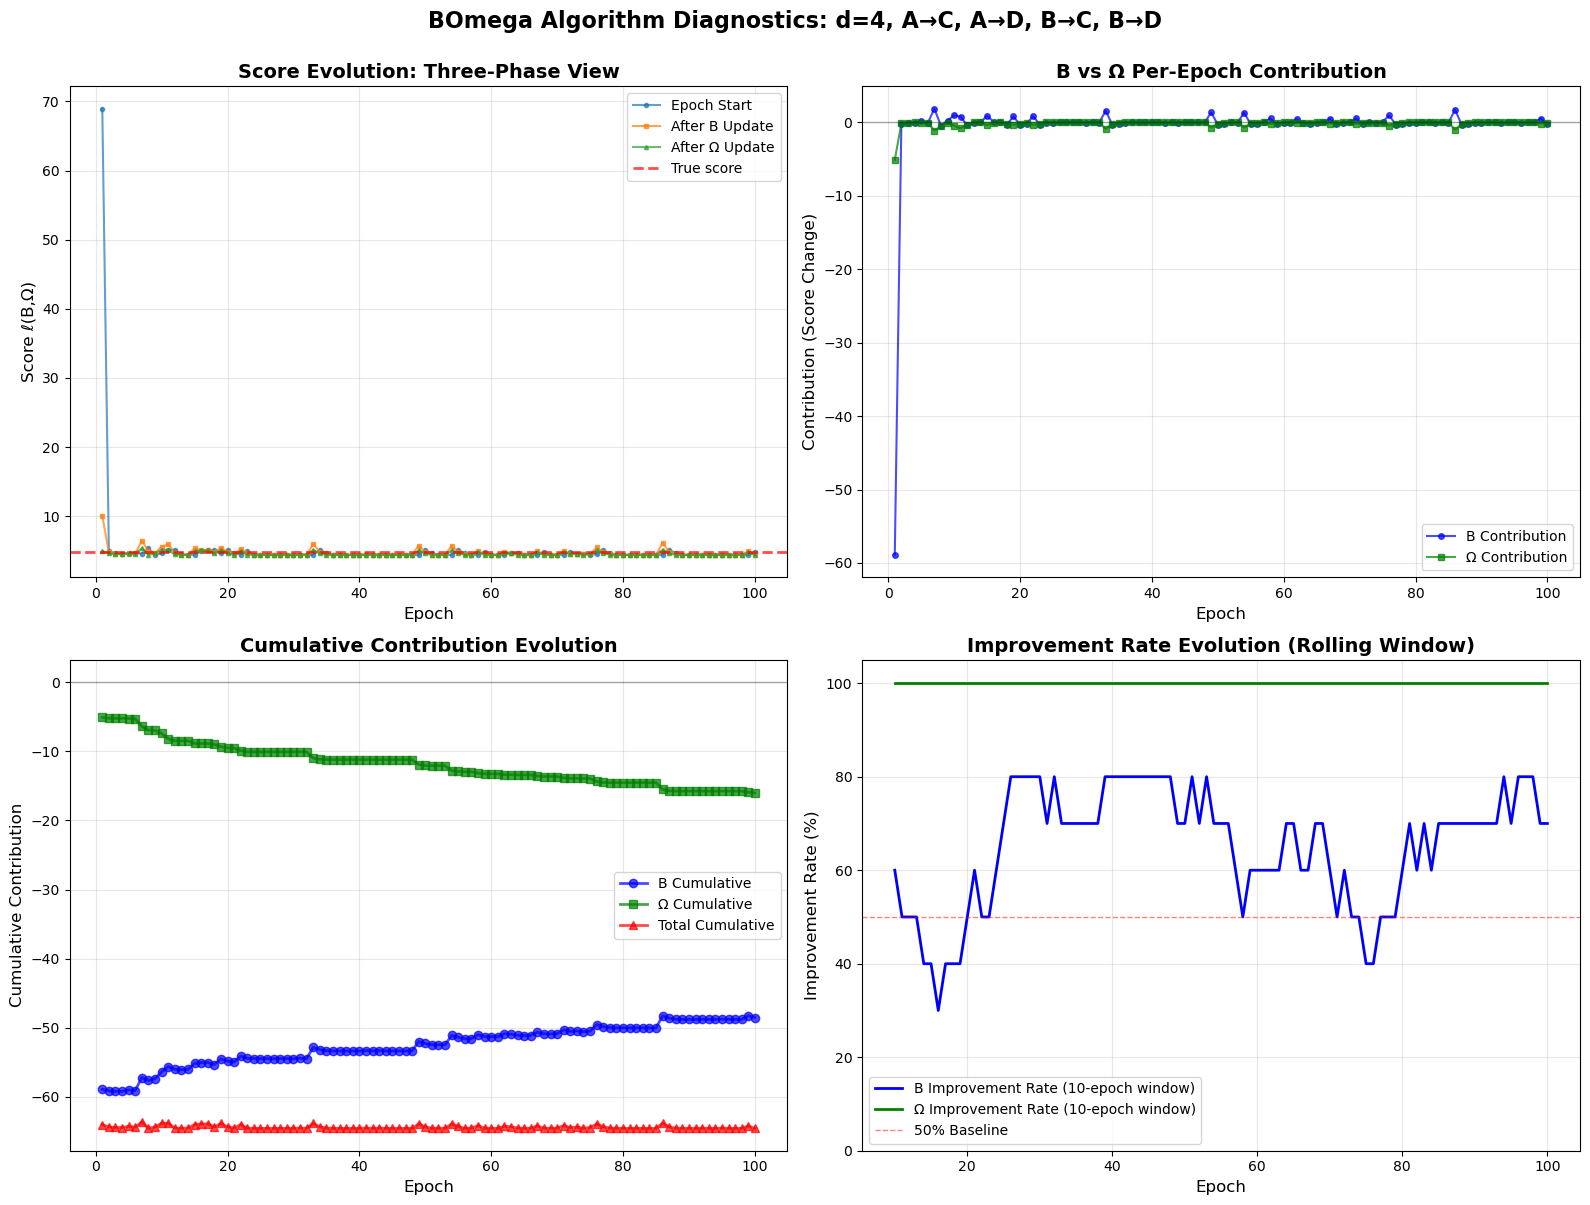

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Score Evolution (Three Phases)
ax = axes[0, 0]
epochs = df['epoch'].values
ax.plot(epochs, df['score_before_B_update'], 'o-', label='Epoch Start', markersize=3, alpha=0.7)
ax.plot(epochs, df['score_after_B_update'], 's-', label='After B Update', markersize=3, alpha=0.7)
ax.plot(epochs, df['score_after_Omega_update'], '^-', label='After Ω Update', markersize=3, alpha=0.7)
ax.axhline(y=score_true, color='red', linestyle='--', linewidth=2, label='True score', alpha=0.7)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Score ℓ(B,Ω)', fontsize=12)
ax.set_title('Score Evolution: Three-Phase View', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: B and Ω Contributions (Per Epoch)
ax = axes[0, 1]
ax.plot(epochs, df['B_contribution'], 'o-', label='B Contribution', markersize=4, alpha=0.7, color='blue')
ax.plot(epochs, df['Omega_contribution'], 's-', label='Ω Contribution', markersize=4, alpha=0.7, color='green')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Contribution (Score Change)', fontsize=12)
ax.set_title('B vs Ω Per-Epoch Contribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 3: Cumulative Contributions
ax = axes[1, 0]
B_cumsum = df['B_contribution'].cumsum()
Omega_cumsum = df['Omega_contribution'].cumsum()
total_cumsum = df['total_change'].cumsum()
ax.plot(epochs, B_cumsum, 'o-', label='B Cumulative', linewidth=2, alpha=0.7, color='blue')
ax.plot(epochs, Omega_cumsum, 's-', label='Ω Cumulative', linewidth=2, alpha=0.7, color='green')
ax.plot(epochs, total_cumsum, '^-', label='Total Cumulative', linewidth=2, alpha=0.7, color='red')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Cumulative Contribution', fontsize=12)
ax.set_title('Cumulative Contribution Evolution', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 4: Improvement/Worsening Statistics (Rolling Window)
ax = axes[1, 1]
window = 10
B_improve_rate = df['B_improves'].rolling(window=window).mean() * 100
Omega_improve_rate = df['Omega_improves'].rolling(window=window).mean() * 100
ax.plot(epochs, B_improve_rate, '-', label=f'B Improvement Rate ({window}-epoch window)', linewidth=2, color='blue')
ax.plot(epochs, Omega_improve_rate, '-', label=f'Ω Improvement Rate ({window}-epoch window)', linewidth=2, color='green')
ax.axhline(y=50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='50% Baseline')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Improvement Rate (%)', fontsize=12)
ax.set_title('Improvement Rate Evolution (Rolling Window)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 105])

plt.suptitle(f'BOmega Algorithm Diagnostics: {experiment["name"]}', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 6. 识别问题epoch

In [15]:
# 找出分数上涨最严重的epoch
print("="*80)
print("分数上涨最严重的Epoch")
print("="*80)

# B更新导致的最大上涨
print("\n1. B更新导致的最大分数上涨（前10）:")
worst_B = df.nlargest(10, 'B_contribution')[['epoch', 'B_contribution', 'Omega_contribution', 'total_change']]
print(worst_B.to_string(index=False))

# Omega更新导致的最大上涨
print("\n2. Ω更新导致的最大分数上涨（前10）:")
worst_Omega = df.nlargest(10, 'Omega_contribution')[['epoch', 'B_contribution', 'Omega_contribution', 'total_change']]
print(worst_Omega.to_string(index=False))

# 总体分数上涨最严重的epoch
print("\n3. 总体分数上涨最严重的Epoch（前10）:")
worst_total = df.nlargest(10, 'total_change')[['epoch', 'B_contribution', 'Omega_contribution', 'total_change']]
print(worst_total.to_string(index=False))

分数上涨最严重的Epoch

1. B更新导致的最大分数上涨（前10）:
 epoch  B_contribution  Omega_contribution  total_change
     7        1.882861           -1.102141      0.780720
    86        1.739360           -0.989691      0.749669
    33        1.606030           -0.887058      0.718972
    49        1.360587           -0.703568      0.657019
    54        1.344601           -0.691896      0.652705
    10        0.983492           -0.450492      0.533000
    76        0.960407           -0.424476      0.535931
    15        0.882142           -0.373760      0.508382
    22        0.850512           -0.353706      0.496807
    19        0.815494           -0.331827      0.483667

2. Ω更新导致的最大分数上涨（前10）:
 epoch  B_contribution  Omega_contribution  total_change
    48       -0.000004       -1.217249e-11     -0.000004
    40       -0.000007       -3.053202e-11     -0.000007
    17       -0.000012       -1.491181e-10     -0.000012
    47       -0.000017       -2.658185e-10     -0.000017
    28       -0.000028      

## 7. 保存诊断结果

In [16]:
# 保存诊断数据到CSV
output_file = "BOmega_diagnostic_results.csv"
df.to_csv(output_file, index=False)
print(f"诊断结果已保存到: {output_file}")

诊断结果已保存到: BOmega_diagnostic_results.csv
